# B · 전체 단일 모델

모든 투수를 **하나의 모델**로 학습하고, 투수 정보는 **ID 인코딩 + 이력 피처**로만 넣는다.

**핵심 질문**: 어떤 모델 계열이 가장 좋은가? 그리고 count-only baseline을 넘는가?

## 설계 결정 (이번 라운드에서 이렇게 했다)

| 축 | 선택 | 이렇게 했다 |
|---|---|---|
| **A. 예측 시점** | A1 엄격 투구 전 | 예측할 투구의 **물리·위치·릴리스각·구종·결과를 전부 입력에서 제외**했다. 상황 + 그 투수/타자의 **과거**만 사용 |
| **B. fit/val 분할** | B3 경기그룹 번갈아 K-fold | `GroupKFold(game_pk)`로 **경기를 통째로** fit/val에 나눠 경기 내 인접투구 누수를 없앴다. **모델 선택에만** 쓰고 **test 2019는 고정**했다 |
| **C. 모델 구조** | C1 전체 단일(투수=ID/이력 피처) | 투수를 나누지 않고 하나의 모델로 학습하고, 투수 구분은 **expanding target encoding + 투수 이력 피처**로만 넣었다 |
| **D. 모델 계열** | 로지스틱 + GBM | LogReg · HistGB · LightGBM · XGBoost를 같은 조건에서 비교했다 (TabPFN은 `05`에서 별도) |
| **E. 투수 ID 처리** | **expanding target encoding**(전 기간 누적 평균 + 수축, `shift(1)` 시간안전) — 원핫은 고카디널리티라 쓰지 않았다 | |
| **F. 튜닝** | 고정 기본값 | 이번 라운드 목적이 **계열 비교**라 하이퍼파라미터는 고정했다 (Optuna 탐색은 `01`·`02`에서 수행) |
| **G. 확률 보정** | 미적용 | isotonic/Platt는 다음 라운드 과제로 남겼다 |
| **H. 평가 프로토콜** | adaptive / prequential | 2019 진행 중 과거 2019 결과로 **이력 피처는 갱신**하되 **모델 파라미터는 2017–18에 고정**했다 |
| **I. 타깃** | 단일 `is_csw` | called_strike + swinging_strike(+blocked) |
| **J. 수축 λ** | 지표별 고정 | csw 200 · whiff 150 · called 150 · zone 200 · chase 120 · fps 100 |
| **K. 표본 범위** | 상위 40투수 | train 238,054 / **test 94,150**. 투수별 모델 임계 `min_train=4,500` |
| **L. 평가지표** | LogLoss(주) | + Brier · PR-AUC · ROC-AUC · ECE 병기 |

> ⚠️ **번갈아 K-fold의 한계**: 시간을 뒤섞으므로 fit 행의 이력피처(`_2w`/`_szn`)가 val 경기 결과를 포함할 수 있다(내삽).
> 그래서 **CV 점수는 2019 test보다 낙관적일 수 있고**, 최종 판단은 항상 **test 2019** 기준으로 했다.

### 사용 피처 — 205개 (쓸 수 있는 것 전부)
- **상황/기본**: 카운트·주자·점수차·이닝·좌우·구장·수비배치·나이·타순바퀴·휴식일·경기내 투구수·직전구종(lag)
- **투수 이력 6지표**(csw/whiff/called/zone/chase/초구스트라이크) × **7창**
  = `_day`(이번 등판) · `_2w`(14일) · `_szn`(시즌누적) · `_pszn`(지난시즌) · **`_car`(전 기간)** · **`_l100`·`_l500`(최근 N구)**
  각 창마다 **비율 + 유효분모(표본수) + 결측지시자**. 지표마다 분모가 다르다(whiff=스윙수, called=테이크수, chase=존밖수…)
- **아스널**: 구종별 평균구속(FF/SI/SL/CH)·패스트볼 구속/사용률·브레이킹 사용률 × **`_2w`·`_szn`·`_car`·`_pszn`**
- **릴리스 반복성**(Kirby 계열, command 아님): VRA/HRA 과거 SD·반복성 지수·FF 표본수·결측
- 모든 이력은 `shift(1)` 시간안전 → 현재 투구 정보 유입 없음

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V2 = Path("out/v2")
meta = json.load(open("cache/meta.json"))
df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = P.baselines(df, tr, te)
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 {len(meta['derived_feats'])}개 | 투수 {meta['top_pitchers']}명")
print("baseline LogLoss:", {k: v["logloss"] for k, v in BASE.items()})

train 238,054 / test 94,150 | 피처 205개 | 투수 40명
baseline LogLoss: {'league_mean': 0.5957, 'count_only': 0.579, 'pitcher_te': 0.5947}


## 1. 모델 계열 비교
CV = 경기그룹 K-fold 5폴드 평균(모델 선택용), TEST = train 전체 재학습 후 2019.

In [2]:
res = {}
for f in sorted(V2.glob("global_*.json")):
    res[f.stem.replace("global_", "")] = json.load(open(f))
rows = {}
for m, r in res.items():
    rows[m] = {"CV_logloss": r["cv_mean"]["logloss"], "TEST_logloss": r["test_2019"]["logloss"],
               "TEST_roc_auc": r["test_2019"]["roc_auc"], "TEST_pr_auc": r["test_2019"]["pr_auc"],
               "TEST_brier": r["test_2019"]["brier"], "TEST_ece": r["test_2019"]["ece"]}
tbl = pd.DataFrame(rows).T.sort_values("TEST_logloss")
tbl["CV-TEST 격차"] = (tbl["TEST_logloss"] - tbl["CV_logloss"]).round(4)
tbl

,CV_logloss,TEST_logloss,TEST_roc_auc,TEST_pr_auc,TEST_brier,TEST_ece,CV-TEST 격차
hgb,0.5727,0.5760,0.6274,0.3862,0.1949,0.0159,0.0033
lgbm,0.5756,0.5772,0.6255,0.3841,0.1954,0.0134,0.0016
logreg,0.5748,0.5789,0.6204,0.3731,0.1961,0.0141,0.0041
xgb,0.5735,0.5810,0.6227,0.3795,0.1972,0.0327,0.0075


## 2. Baseline 대비
`count_only` = `P(CSW | balls, strikes, stand, p_throws)`. **이 선을 넘는지가 실질 성능의 기준**이다.

In [3]:
b = pd.DataFrame({k: {"logloss": v["logloss"], "roc_auc": v["roc_auc"]} for k, v in BASE.items()}).T
best = tbl["TEST_logloss"].min()
print(f"최고 모델 TEST LogLoss {best:.4f} | count-only 대비 {best-BASE['count_only']['logloss']:+.4f} | 리그평균 대비 {best-BASE['league_mean']['logloss']:+.4f}")
b

최고 모델 TEST LogLoss 0.5760 | count-only 대비 -0.0030 | 리그평균 대비 -0.0197


,logloss,roc_auc
league_mean,0.5957,0.5000
count_only,0.5790,0.6142
pitcher_te,0.5947,0.5295


## 3. CV vs TEST 격차
격차가 크면 번갈아 K-fold의 **내삽 편향**(시간 뒤섞기)이 작동한 것이다.

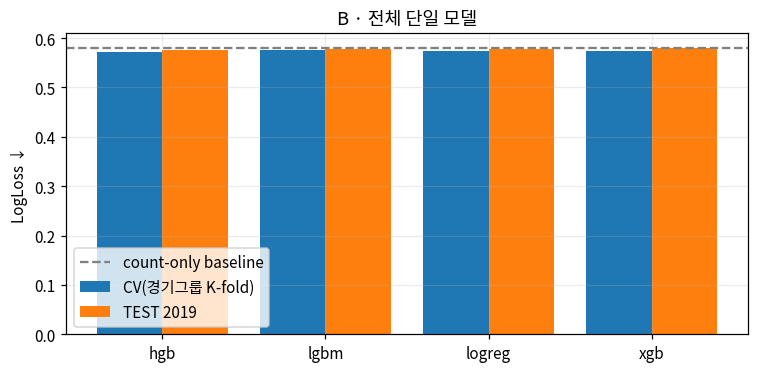

,CV_logloss,TEST_logloss,CV-TEST 격차
hgb,0.5727,0.5760,0.0033
lgbm,0.5756,0.5772,0.0016
logreg,0.5748,0.5789,0.0041
xgb,0.5735,0.5810,0.0075


In [4]:
plt.figure(figsize=(7,3.5))
x = np.arange(len(tbl)); plt.bar(x-0.2, tbl["CV_logloss"], 0.4, label="CV(경기그룹 K-fold)")
plt.bar(x+0.2, tbl["TEST_logloss"], 0.4, label="TEST 2019")
plt.axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only baseline")
plt.xticks(x, tbl.index); plt.ylabel("LogLoss ↓"); plt.title("B · 전체 단일 모델"); plt.legend(); plt.tight_layout(); plt.show()
tbl[["CV_logloss","TEST_logloss","CV-TEST 격차"]]